# Aims
This notebook analyses the results of this experiment.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import re

sns.set_style("whitegrid")

In [25]:
def load_data():
    
    data = []
    
    for f in Path("./results").glob("**/metrics.csv"):
        
        instance = f.parent.parent.name
        n = int(re.match("n=(\d)", f.parent.parent.parent.name).groups()[0])
        
        _df = pd.read_csv(f)
        
        _df["instance"] = instance
        _df["n"] = n
        
        data.append(_df)
        
    return pd.concat(data)

In [28]:
df = load_data()

In [29]:
df

,epoch,step,train_epoch_duration,instance,n
0,0,60,6.128371,instance4,5
1,1,121,5.425508,instance4,5
2,2,182,5.616339,instance4,5
3,3,243,5.386866,instance4,5
4,4,304,5.403458,instance4,5
...,...,...,...,...,...
95,95,5855,4.208011,instance3,4
96,96,5916,4.169991,instance3,4
97,97,5977,3.693419,instance3,4
98,98,6038,3.029598,instance3,4


In [43]:
summary = df.loc[:, ["n","train_epoch_duration"]].groupby("n").describe()

In [44]:
summary

train_epoch_duration                                                    \
                 count      mean       std       min       25%       50%   
n                                                                          
1                100.0  1.664950  0.054270  1.566145  1.630038  1.660993   
2                200.0  2.548136  0.294893  1.960546  2.296620  2.570240   
3                300.0  3.004786  0.136150  2.032335  2.985038  3.018103   
4                400.0  4.131146  0.311205  1.600300  4.071484  4.180351   
5                500.0  5.309954  0.390929  2.318010  5.302320  5.361951   

                       
        75%       max  
n                      
1  1.698375  1.947242  
2  2.824195  3.020397  
3  3.064072  3.323161  
4  4.277231  4.823386  
5  5.421020  6.252887

<Axes: xlabel='n'>

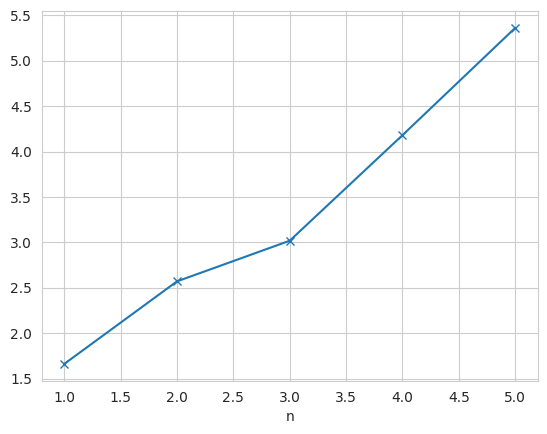

In [59]:
summary.loc[:, (slice(None), "50%")].plot(legend=None, marker="x")

/tmp/ipykernel_44875/3166614839.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxenplot(df, x="n", y="train_epoch_duration", hue="n", palette=sns.husl_palette(), ax=ax, legend=None)


Text(0.5, 0, 'Number of concurrent model training')

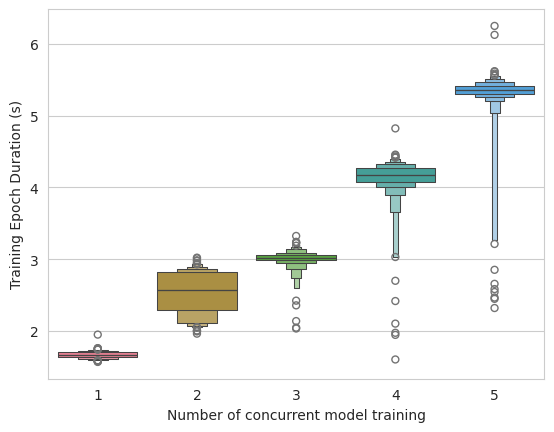

In [54]:
f, ax = plt.subplots()

sns.boxenplot(df, x="n", y="train_epoch_duration", hue="n", palette=sns.husl_palette(), ax=ax, legend=None)
ax.set_ylabel("Training Epoch Duration (s)")
ax.set_xlabel("Number of concurrent model training")